# Data Exploration and experiment

This notebook is created to practice and work on historical stock price data.  
I referred to "Machine Learning and Data Science Blueprints for Finance" by Hariom Tatsat et al., By O'reilly media and lab notebook "Unleashing the Power of Reinforcement Learning for Trading" by IBM 👉 [Link](https://cognitiveclass.ai/courses/unleashing-the-power-of-reinforcement-learning-for-trading)

I used the dtype_backend = 'pyarrow' and that caused an issue when I used my dataset in "ta" library. The "ta" doesn't support pyarrow datatypes. 
```python
pd.read_parquet(file_path, engine='pyarrow', dtype_backend='pyarrow')
```
![Description](assets/pyarrow-dtype.png)


In [231]:
import pandas as pd
# To load the parquet file data into pandas dataframe
def load_parquet(file_path: str) -> pd.DataFrame:
    try:
        data = pd.read_parquet(file_path, engine='pyarrow')
        return data
    except Exception as e:
        print(f"An error occurred while importing data: {e}")
        return pd.DataFrame()

### Exploratory Data Analysis (EDA)
#### Descriptive statistics
I referred the Machine Learning and Data Science Blueprints for Finance book by Hariom Tatsat et al [link](https://learning.oreilly.com/library/view/machine-learning-and/9781492073048/ch02.html#idm45864694385896). 


In [232]:
# Loading the data
from pathlib import Path

ds_csco = load_parquet("parquet_train_data/CSCO.parquet")

In [233]:
print("✅ Beginning of the data view")
display(ds_csco.head())
print("\n✅ Shape of the data: ", ds_csco.shape)
print("\n✅ Data type of the index: ", ds_csco.index.dtype)
print("\n✅ Data types of the columns:", ds_csco.dtypes)
print("\n✅ Summary statistics of the data:")
display(ds_csco.describe())

✅ Beginning of the data view


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1990-02-16,0.0,0.079861,0.073785,0.077257,0.059806,940636800
1990-02-20,0.0,0.079861,0.074653,0.079861,0.061822,151862400
1990-02-21,0.0,0.078993,0.075521,0.078125,0.060478,70531200
1990-02-22,0.0,0.081597,0.078993,0.078993,0.061150,45216000
1990-02-23,0.0,0.079861,0.078125,0.078559,0.060814,44697600



✅ Shape of the data:  (7589, 6)

✅ Data type of the index:  datetime64[us]

✅ Data types of the columns: Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

✅ Summary statistics of the data:


,Open,High,Low,Close,Adj Close,Volume
count,7589.000000,7589.000000,7589.000000,7589.000000,7589.000000,7.589000e+03
mean,20.404527,20.682047,20.116294,20.399541,16.945200,5.680188e+07
std,14.915392,15.133191,14.676149,14.906589,13.253297,4.168727e+07
min,0.000000,0.072917,0.068576,0.071181,0.055102,8.064000e+05
25%,8.444445,8.583333,8.326389,8.479167,6.563846,3.245060e+07
50%,19.700001,19.937500,19.440001,19.680000,15.311988,4.898850e+07
75%,27.129999,27.410000,26.830000,27.120001,21.845076,6.822650e+07
max,81.437500,82.000000,79.062500,80.062500,61.977535,9.406368e+08


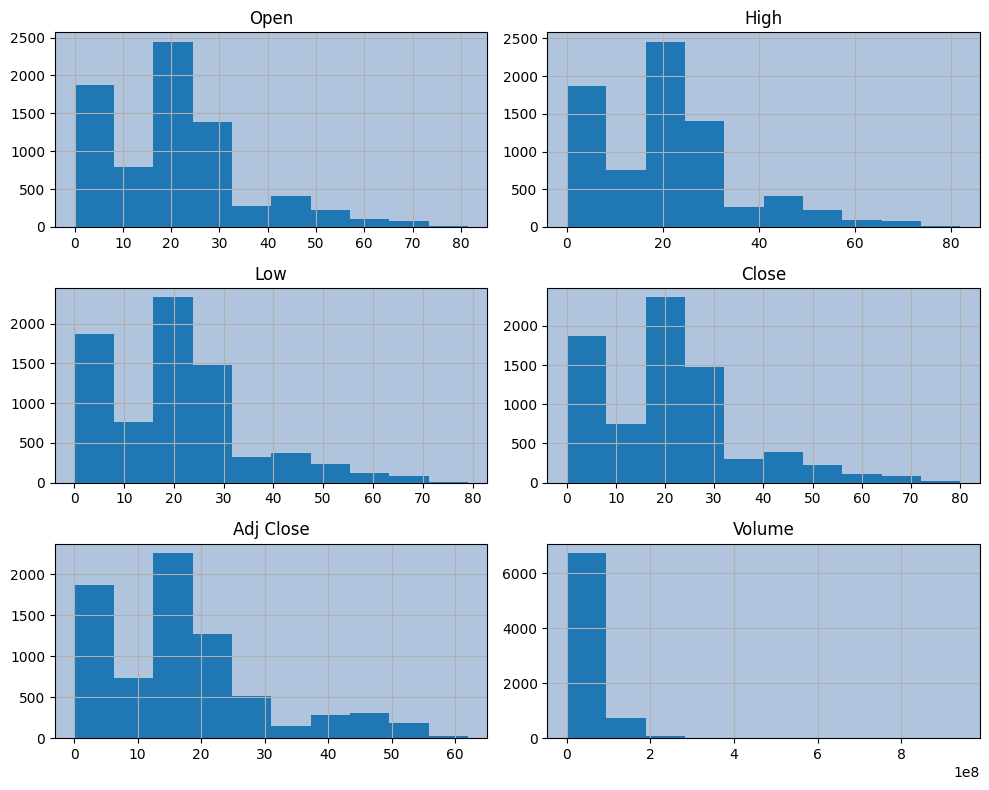

In [234]:
#### Data Visualization
import matplotlib.pyplot as plt
ds_csco.hist(sharex=False, sharey=False, figsize=(10, 8))
plt.tight_layout()

Text(0.5, 1.0, 'Volume (Excluding top 5% Outliers)')

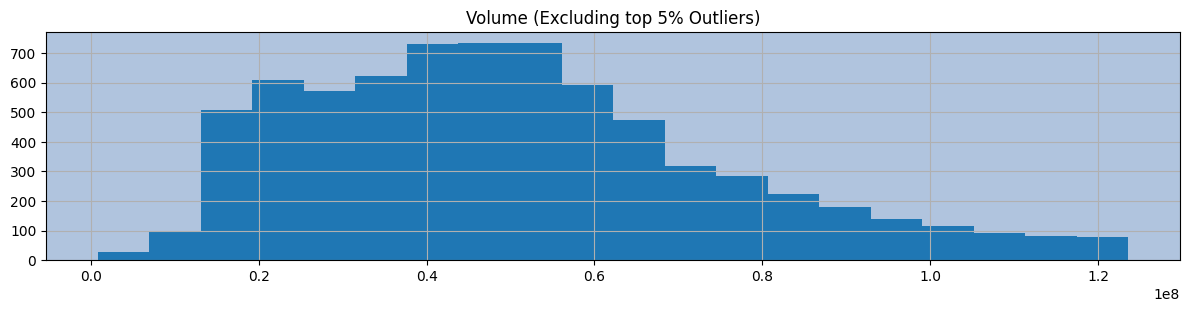

In [235]:
outliers = ds_csco['Volume'].quantile(0.95)
ds_csco[ds_csco['Volume'] < outliers]['Volume'].hist(bins=20, figsize=(12, 3))
plt.tight_layout()
plt.title("Volume (Excluding top 5% Outliers)")

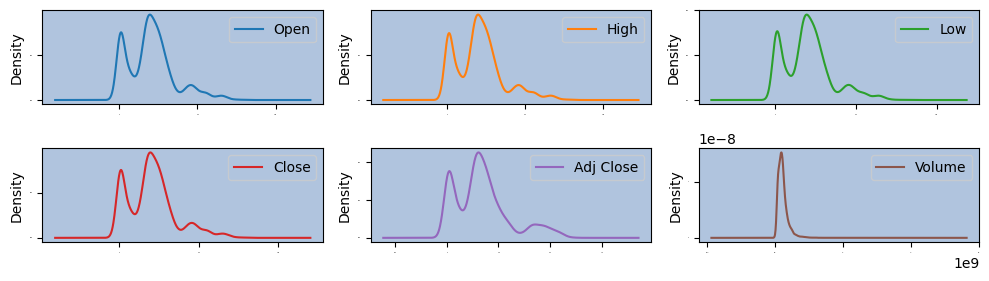

In [236]:
ds_csco.plot(kind='density', subplots=True, layout=(3,3), sharex=False,\
legend=True, fontsize=1, figsize=(10,4))
plt.tight_layout()

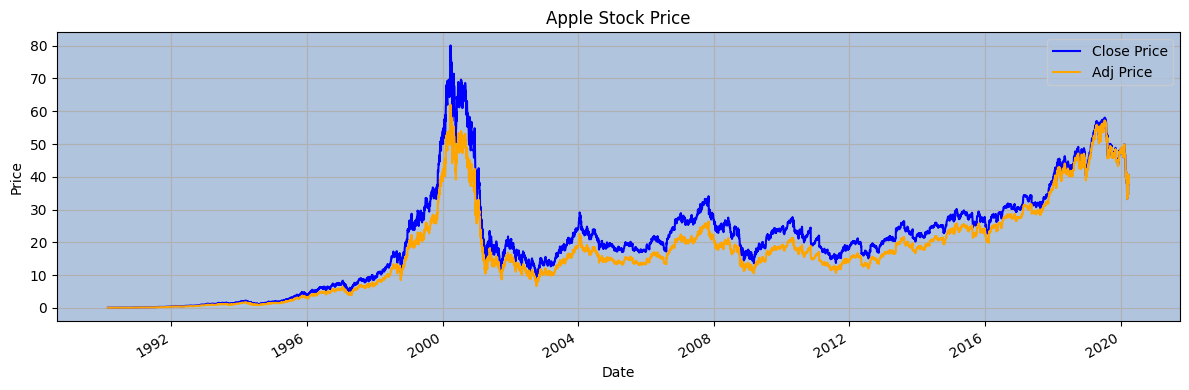

In [237]:
fig, ax = plt.subplots(figsize=(12, 4))
ds_csco.plot(y='Close', ax=ax, label='Close Price', color='blue')
ds_csco.plot(y='Adj Close', ax=ax, label='Adj Price', color='orange')
ax.set_title("Apple Stock Price")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.grid(True)
fig.tight_layout()
plt.show()


### Data Cleaning


In [238]:
# check duplicate rows
def check_duplicate(ds: pd.DataFrame):
    duplicate_rows = ds.duplicated().sum()
    if duplicate_rows > 0:
        ds = ds.drop_duplicates()
        print(f"\n✅Cleaned {duplicate_rows} from the dataset")
    return ds

In [239]:
# Integrity checks
def check_integrity(ds: pd.DataFrame):
    if not (ds[['Open', 'High', 'Low', 'Close']] >= 0).all().all():
        # only return the rows with positive prices
        valid_rows = (ds[['Open', 'High', 'Low', 'Close']] >= 0).all(axis=1)
        ds = ds[valid_rows]
    if not (ds['High'] >= ds['Low']).all():
        # only return the rows with High >= Low
        valid_rows = (ds['High'] >= ds['Low'])
        ds = ds[valid_rows]
    if not (ds['Volume'] > 0).all():
        # only return the rows with Volume > 0
        valid_rows = (ds['Volume'] > 0)
        ds = ds[valid_rows]
    return ds


In [240]:
print("\n🍀 Before checking duplicates, the shape of the data: ", ds_csco.shape)
ds_csco = check_duplicate(ds_csco)
print("\n🍋 After checking duplicates, the shape of the data: ", ds_csco.shape)
print("\n","="*60)
print("\n🍀 Before checking integrity, the shape of the data: ", ds_csco.shape)
ds_csco = check_integrity(ds_csco)
print("\n🍋 After checking integrity, the shape of the data: ", ds_csco.shape)



🍀 Before checking duplicates, the shape of the data:  (7589, 6)

🍋 After checking duplicates, the shape of the data:  (7589, 6)


🍀 Before checking integrity, the shape of the data:  (7589, 6)

🍋 After checking integrity, the shape of the data:  (7589, 6)


In [241]:
print(type(ds_csco['Close']))

<class 'pandas.Series'>


### Feature Engineering

#### Technical Analysis Indicators

I referred the IBM ["Unleashing the Power of Reinforcement Learning for Trading"](https://cognitiveclass.ai/courses/unleashing-the-power-of-reinforcement-learning-for-trading) lab tutorial for the TA.

##### Exponential Moving Average

In [242]:
import ta
ds_csco['EMA14'] = ta.trend.EMAIndicator(close= ds_csco['Close'], window= 14, fillna= False).ema_indicator()
ds_csco['EMA50'] = ta.trend.EMAIndicator(close= ds_csco['Close'], window= 50, fillna= False).ema_indicator()
ds_csco['EMA200'] = ta.trend.EMAIndicator(close= ds_csco['Close'], window= 200, fillna= False).ema_indicator()

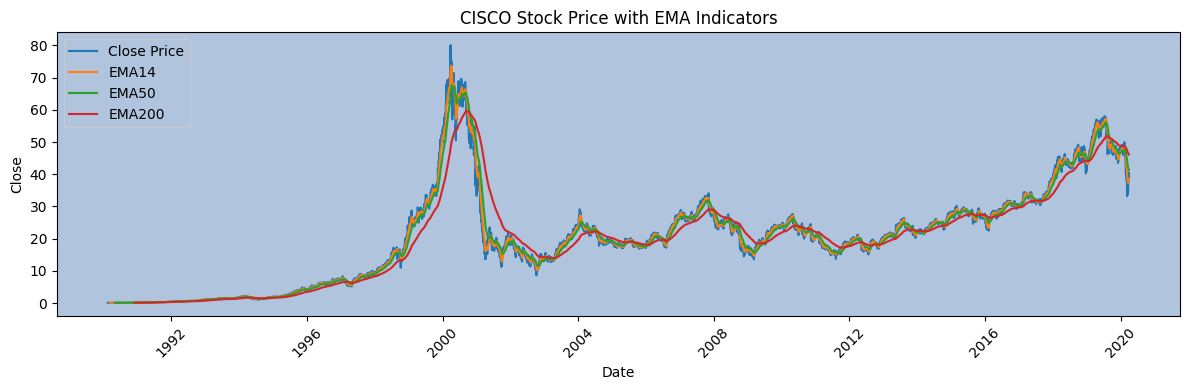

In [243]:
import seaborn as sns
sns.set_style(rc = {'axes.facecolor': 'lightsteelblue'})
plt.figure(figsize=(12,4))
# Create line plot
sns.lineplot(x=pd.to_datetime(ds_csco.index), y=ds_csco["Close"], label = "Close Price")
sns.lineplot(x=pd.to_datetime(ds_csco.index), y=ds_csco["EMA14"], label = "EMA14")
sns.lineplot(x=pd.to_datetime(ds_csco.index), y=ds_csco["EMA50"], label = "EMA50")
sns.lineplot(x=pd.to_datetime(ds_csco.index), y=ds_csco["EMA200"], label = "EMA200")
plt.xticks(rotation=45)
plt.title("CISCO Stock Price with EMA Indicators")
plt.tight_layout()

In [ ]:
# The sigmoid is used in OBV in later in the notebook. 
import numpy as np
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

##### Momentum Indicators
MACD - Moving Average Convergence/Divergence

In [245]:
macd =ta.trend.MACD(close=ds_csco['Close'], window_slow= 26, window_fast= 12, window_sign = 9, fillna = False) 
ds_csco['MACD_line'] =macd.macd()
ds_csco['MACD_signal'] =macd.macd_signal()
ds_csco['MACD_diff'] =macd.macd_diff()

RSI - Relative Strength Index 

In [246]:
ds_csco['RSI']=ta.momentum.RSIIndicator(close= ds_csco['Close'], window= 14, fillna= False).rsi()

In [247]:
display(ds_csco[['Close', 'Volume', 'MACD_signal', 'MACD_line', 'MACD_diff']].sample(n=5))

,Close,Volume,MACD_signal,MACD_line,MACD_diff
Date,,,,,
2009-09-11,23.090000,53497100,0.243819,0.341753,0.097934
2010-07-19,22.730000,54701900,-0.226664,-0.042035,0.184629
2014-05-20,24.120001,56321600,0.208065,0.329173,0.121108
1993-11-03,1.416667,86364000,0.014565,0.025350,0.010785
2010-06-15,23.330000,77834700,-0.739394,-0.645920,0.093474


#### Volume Indicator
The IBM lab used the On-Balance Volume (OBV) indicator. The OBV indicator accumulates the volume on up days by adding and down days by subtracting the daily volumes. But it seems pretty difficult to normalize such values as it is unbounded and can grow continuously to larger numbers. I will try using sigmoid function to normalize the OBV, but I assume the value would be always closer to 1 or 0. 

In [248]:
print("The Close Values are all positive:", (ds_csco['Close'] > 0).all())
print("The Close Values have missing values:", ds_csco['Close'].isnull().any())
print("The Volume Values have missing values:", ds_csco['Volume'].isnull().any())

The Close Values are all positive: True
The Close Values have missing values: False
The Volume Values have missing values: False


In [249]:
ds_csco['Close'] = ds_csco['Close'].astype('float64')
ds_csco['Volume'] = ds_csco['Volume'].astype('float64')
print("The Close Values are all positive:", (ds_csco['Close'] > 0).all())
print("The Close Values have missing values:", ds_csco['Close'].isnull().any())
print("The Volume Values have missing values:", ds_csco['Volume'].isnull().any())

The Close Values are all positive: True
The Close Values have missing values: False
The Volume Values have missing values: False


In [250]:
print(ds_csco['Close'].dtype)

float64


In [251]:
ds_csco['OBV']= ta.volume.OnBalanceVolumeIndicator(close=ds_csco['Close'], volume=ds_csco['Volume'], fillna = False).on_balance_volume()

In [252]:
display(ds_csco[['Close', 'Volume', 'OBV']].head())

,Close,Volume,OBV
Date,,,
1990-02-16,0.077257,940636800.0,9.406368e+08
1990-02-20,0.079861,151862400.0,1.092499e+09
1990-02-21,0.078125,70531200.0,1.021968e+09
1990-02-22,0.078993,45216000.0,1.067184e+09
1990-02-23,0.078559,44697600.0,1.022486e+09


Since the OBV value is too big, I decided to use Sigmoid to normalize that data for my RL training.

In [253]:
ds_csco['OBV_norm'] = sigmoid(ds_csco['OBV'])


In [254]:
display(ds_csco[['Volume', 'OBV', 'OBV_norm']].sample(n=5))

,Volume,OBV,OBV_norm
Date,,,
2000-12-20,167411300.0,2.371909e+10,1.0
2000-12-27,47381700.0,2.380547e+10,1.0
2016-10-24,14115300.0,2.896297e+10,1.0
2004-06-16,44052400.0,2.609951e+10,1.0
1999-10-26,38695000.0,2.303765e+10,1.0


As shown below, there is no negative values for the OBV, which in this case not useful for training the model. 

In [255]:
# display OBV_norm negative values
display(ds_csco[ds_csco['OBV'] < 0][['Volume', 'OBV', 'OBV_norm']])

,Volume,OBV,OBV_norm
Date,,,


##### Normalization
I need to normalize the data values for ML training and for generalization. 

Z-Score:
$z=(x-\mu)/\sigma$

In [256]:
def rsi_norm(ds: pd.DataFrame) -> pd.DataFrame:
    df = ds.copy()
    df['rsi_norm'] = (df['RSI'] - 50) / 50.0
    return df
# assuming 52-weeks trading days are 260 daily data periods
def macd_norm(ds: pd.DataFrame, window: int = 260) -> pd.DataFrame:
    df = ds.copy()
    mean = df['MACD_line'].rolling(window=window).mean()
    std = df['MACD_line'].rolling(window=window).std()
    df['MACD_line_norm'] = (df['MACD_line'] - mean) / (std + 1e-8) # adding epsilon to avoid division error
    df['MACD_signal_norm'] = (df['MACD_signal'] - mean) / (std + 1e-8)
    df['MACD_diff_norm'] = df['MACD_line_norm'] - df['MACD_signal_norm']
    return df

In [257]:
def volume_norm(ds: pd.DataFrame, window: int = 260) -> pd.DataFrame:
    df = ds.copy()
    log_volume = np.log1p(df['Volume'])
    mean = log_volume.rolling(window=window).mean()
    std = log_volume.rolling(window=window).std()
    df['Volume_norm'] = (log_volume - mean) / (std + 1e-8)
    return df

In [258]:
ds_csco = rsi_norm(ds_csco)
print("RSI normalized and data shape is: ", ds_csco.shape)

RSI normalized and data shape is:  (7589, 16)


In [259]:
ds_csco = macd_norm(ds_csco)
print("MACD normalized and data shape is: ", ds_csco.shape)

MACD normalized and data shape is:  (7589, 19)


In [260]:
ds_csco = volume_norm(ds_csco)
print("Volume normalized and data shape is: ", ds_csco.shape)

Volume normalized and data shape is:  (7589, 20)


In [261]:
display(ds_csco.head())

,Open,High,Low,Close,Adj Close,Volume,EMA14,EMA50,EMA200,MACD_line,MACD_signal,MACD_diff,RSI,OBV,OBV_norm,rsi_norm,MACD_line_norm,MACD_signal_norm,MACD_diff_norm,Volume_norm
Date,,,,,,,,,,,,,,,,,,,,
1990-02-16,0.0,0.079861,0.073785,0.077257,0.059806,940636800.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.406368e+08,1.0,NaN,NaN,NaN,NaN,NaN
1990-02-20,0.0,0.079861,0.074653,0.079861,0.061822,151862400.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.092499e+09,1.0,NaN,NaN,NaN,NaN,NaN
1990-02-21,0.0,0.078993,0.075521,0.078125,0.060478,70531200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.021968e+09,1.0,NaN,NaN,NaN,NaN,NaN
1990-02-22,0.0,0.081597,0.078993,0.078993,0.061150,45216000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.067184e+09,1.0,NaN,NaN,NaN,NaN,NaN
1990-02-23,0.0,0.079861,0.078125,0.078559,0.060814,44697600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.022486e+09,1.0,NaN,NaN,NaN,NaN,NaN


In [262]:
# removing the first 260 rows as it has missing values as I used 260-day rolling window for normalization
ds_csco = ds_csco.iloc[260:]
print("After removing the first 260 rows, the shape of the data: ", ds_csco.shape)

After removing the first 260 rows, the shape of the data:  (7329, 20)


In [263]:
display(ds_csco.head(26))

,Open,High,Low,Close,Adj Close,Volume,EMA14,EMA50,EMA200,MACD_line,MACD_signal,MACD_diff,RSI,OBV,OBV_norm,rsi_norm,MACD_line_norm,MACD_signal_norm,MACD_diff_norm,Volume_norm
Date,,,,,,,,,,,,,,,,,,,,
1991-02-28,0.188368,0.195747,0.187500,0.194444,0.150522,132624000.0,0.196113,0.178287,0.130114,0.004420,0.007611,-0.003191,53.285069,4.328150e+09,1.0,0.065701,NaN,NaN,NaN,1.111833
1991-03-01,0.195312,0.199653,0.193576,0.197917,0.153210,91641600.0,0.196354,0.179056,0.130789,0.004231,0.006935,-0.002705,56.397716,4.419792e+09,1.0,0.127954,NaN,NaN,NaN,0.786554
1991-03-04,0.200521,0.201389,0.198785,0.200521,0.155226,60019200.0,0.196909,0.179898,0.131483,0.004242,0.006397,-0.002155,58.624419,4.479811e+09,1.0,0.172488,NaN,NaN,NaN,0.410570
1991-03-05,0.201389,0.207465,0.199653,0.207465,0.160602,138124800.0,0.198317,0.180979,0.132239,0.004756,0.006068,-0.001312,63.916400,4.617936e+09,1.0,0.278328,NaN,NaN,NaN,1.145843
1991-03-06,0.209201,0.210938,0.197917,0.197917,0.153210,164505600.0,0.198263,0.181644,0.132892,0.004343,0.005723,-0.001380,53.738729,4.453430e+09,1.0,0.074775,NaN,NaN,NaN,1.292445
1991-03-07,0.197917,0.198351,0.184028,0.190104,0.147162,379987200.0,0.197175,0.181975,0.133462,0.003347,0.005248,-0.001901,47.126657,4.073443e+09,1.0,-0.057467,NaN,NaN,NaN,2.008929
1991-03-08,0.192708,0.197917,0.190972,0.192708,0.149178,132969600.0,0.196580,0.182396,0.134051,0.002736,0.004746,-0.002010,49.363205,4.206413e+09,1.0,-0.012736,NaN,NaN,NaN,1.078925
1991-03-11,0.191840,0.191840,0.179688,0.184028,0.142459,154742400.0,0.194906,0.182460,0.134548,0.001534,0.004103,-0.002570,42.855695,4.051670e+09,1.0,-0.142886,NaN,NaN,NaN,1.206224
1991-03-12,0.182292,0.182292,0.171875,0.171875,0.133051,223430400.0,0.191835,0.182045,0.134920,-0.000395,0.003204,-0.003599,35.750085,3.828240e+09,1.0,-0.284998,NaN,NaN,NaN,1.513982


The preceding code result shows that the MACD was calculated with the missing MACD values. I better to use dropna method to skip the missing values. 

In [264]:
ds_csco = ds_csco.dropna()

In [265]:
print("After dropping NA values, the shape of the data: ", ds_csco.shape)

After dropping NA values, the shape of the data:  (7305, 20)


In [266]:
display(ds_csco.head())

,Open,High,Low,Close,Adj Close,Volume,EMA14,EMA50,EMA200,MACD_line,MACD_signal,MACD_diff,RSI,OBV,OBV_norm,rsi_norm,MACD_line_norm,MACD_signal_norm,MACD_diff_norm,Volume_norm
Date,,,,,,,,,,,,,,,,,,,,
1991-04-04,0.178819,0.185764,0.175347,0.177083,0.137083,147859200.0,0.177731,0.179474,0.141106,-0.003717,-0.003815,0.000099,48.240857,3.983688e+09,1.0,-0.035183,-1.386060,-1.407078,0.021018,1.004822
1991-04-05,0.177083,0.178819,0.159722,0.174479,0.135067,168753600.0,0.177298,0.179278,0.141439,-0.003651,-0.003783,0.000131,47.128856,3.814934e+09,1.0,-0.057423,-1.363459,-1.391320,0.027860,1.108740
1991-04-08,0.171875,0.182292,0.170139,0.180556,0.139771,40939200.0,0.177732,0.179328,0.141828,-0.003074,-0.003641,0.000567,50.023648,3.855874e+09,1.0,0.000473,-1.233664,-1.353747,0.120082,-0.081861
1991-04-09,0.180556,0.180556,0.175347,0.177083,0.137083,45403200.0,0.177646,0.179240,0.142179,-0.002863,-0.003485,0.000622,48.393115,3.810470e+09,1.0,-0.032138,-1.182497,-1.313896,0.131399,0.000079
1991-04-10,0.177083,0.180556,0.175347,0.176215,0.136411,56433600.0,0.177455,0.179122,0.142517,-0.002735,-0.003335,0.000600,47.972130,3.754037e+09,1.0,-0.040557,-1.149156,-1.275655,0.126498,0.179483


In [268]:
print('Null Values =', ds_csco.isnull().values.any())

Null Values = False


### Price data conversion
According to the "Python for Finance Cookbook - Second Edition" by Erik Lewison, by transforming the prices to returns, we attempt to make the prices stationary which usually non-stationary. It also normalizes the prices. 


In [271]:
ds_csco['Prev_close'] = ds_csco['Close'].shift(1)

Using the log return method for the Close price normalization. 

In [272]:
ds_csco['Return'] = np.log(ds_csco['Close']) - np.log(ds_csco['Prev_close'])

In [274]:
display(ds_csco[['Close', 'Prev_close', 'Return']].sample(n=5))

,Close,Prev_close,Return
Date,,,
2006-05-30,19.7700,20.309999,-0.026948
1999-10-19,33.6875,33.687500,0.000000
2001-06-07,21.8200,20.760000,0.049799
2016-09-26,31.0700,31.340000,-0.008653
2006-07-25,18.0700,17.950001,0.006663


### Target price for trend prediction

I choose to use the price in 30 days to calculate the trend as the price can fluctuate a lot in short period. 

In [269]:
# price in 30 days as a target value
ds_csco['Target'] = ds_csco['Close'].shift(-30)

In [270]:
# If return is more than 5% in 30 days, then use 1 as buy, if return is less than -5% in 30 days, then use 2 as sell, otherwise use 0 as hold
reward = (ds_csco['Target'] - ds_csco['Close']) / ds_csco['Close']
ds_csco['Signal'] = 0
ds_csco.loc[reward > 0.05, 'Signal'] = 1
ds_csco.loc[reward < -0.05, 'Signal'] = 2

# But I just realized that I don't need to do this in my dataset, because my RL Agent will get the reward based on the action it takes from the environment. The environment should calculate the reward based on the accuracy of the predicted action as a feedback. The Raw target and close values are required for the environment to calculate the reward. 

Multivariate plot

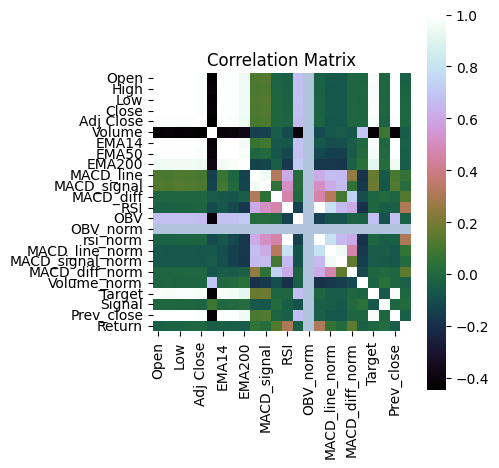

In [277]:
import seaborn as sns
correlation = ds_csco.corr()
plt.figure(figsize=(5,5))
plt.title('Correlation Matrix')
sns.heatmap(correlation, vmax=1, square=True,annot=False,cmap='cubehelix')
plt.tight_layout()

## Conclusion

🍀 Done - Exploratory Data Analysis.  
🍀 Done - Data cleaning.  
🍀 Done - Feature engineering.  

Now ready to preprocessing the whole datasets in 1_3_data_preprocessing.ipynb. 

|Date (YYYY-MM-DD)|Version|Created By|  
|--|--|--|
|2026-02-26|1.0|Battogtokh Baasanjav|